In [1]:
# Install if needed
# !pip install pandas scikit-learn nltk matplotlib seaborn

import pandas as pd
import numpy as np

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

# ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [3]:
df = pd.read_csv("scraped_data_ufcstats.csv", low_memory=False)

# Convert percentage columns to numeric
cols = [
    "B_Round_Three_Significant_Strike_Perc",
    "B_Round_Four_Significant_Strike_Perc",
    # add others...
]

for col in cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")


In [6]:
df = df.copy()

df['text'] = (
    df[existing_columns]
    .fillna('')
    .astype(str)
    .apply(lambda row: ' '.join(row), axis=1)
)

In [7]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)  # remove punctuation
    
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    
    return ' '.join(words)

df['clean_text'] = df['text'].apply(clean_text)

In [8]:
vectorizer = TfidfVectorizer(max_features=500)

X = vectorizer.fit_transform(df['clean_text'])

print(X.shape)

(6203, 35)


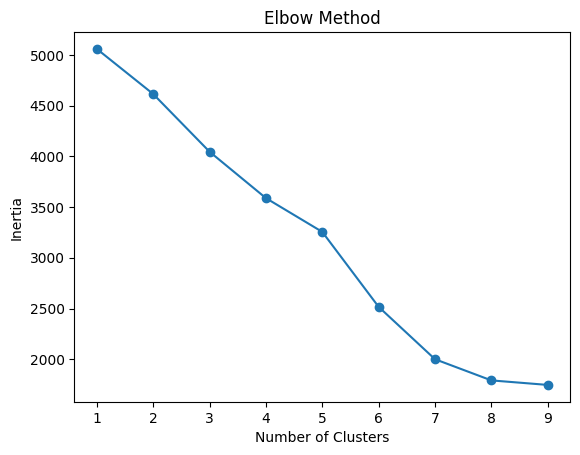

In [9]:
inertia = []

K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [10]:
k = 4  # choose based on elbow plot

kmeans = KMeans(n_clusters=k, random_state=42)
df['cluster'] = kmeans.fit_predict(X)

df.head()

,event_date,weight_class,max_rounds,ending_round,winner,win_by,b_name,b_age,b_height,b_weight,...,r_round_five_total_strikes_landed,r_round_five_takedowns_attempted,r_round_five_takedowns_landed,r_round_five_takedown_perc,r_round_five_submission_attempts,r_round_five_grappling_reversals,r_round_five_grappling_control_time,text,clean_text,cluster
0,2022-03-19,Heavyweight,5,1,Blue,SUB,Tom Aspinall,28,77,256,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SUB Heavyweight,sub heavyweight,0
1,2022-03-19,Featherweight,3,1,Red,KO/TKO,Dan Hooker,32,72,145,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,KO/TKO Featherweight,kotko featherweight,1
2,2022-03-19,Lightweight,3,1,Red,SUB,Kazula Vargas,36,68,155,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SUB Lightweight,sub lightweight,3
3,2022-03-19,Welterweight,3,3,Red,DEC,Takashi Sato,31,70,170,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DEC Welterweight,dec welterweight,2
4,2022-03-19,Women's Flyweight,3,3,Red,KO/TKO,Luana Carolina,28,66,125,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,KO/TKO Women's Flyweight,kotko womens flyweight,0


In [11]:
for i in range(k):
    print(f"\nCluster {i}:")
    print(df[df['cluster'] == i]['text'].head(10))


Cluster 0:
0              SUB Heavyweight
4     KO/TKO Women's Flyweight
7           KO/TKO Heavyweight
8        SUB Light Heavyweight
12       DEC Light Heavyweight
13         KO/TKO Bantamweight
15    KO/TKO Light Heavyweight
19       DEC Women's Flyweight
24         KO/TKO Bantamweight
25    KO/TKO Light Heavyweight
Name: text, dtype: str

Cluster 1:
1      KO/TKO Featherweight
6         SUB Featherweight
11            SUB Flyweight
14        DEC Featherweight
21        SUB Featherweight
22    SUB Women's Flyweight
23         SUB Middleweight
28        DEC Featherweight
34    SUB Women's Flyweight
35        SUB Featherweight
Name: text, dtype: str

Cluster 2:
3            DEC Welterweight
9            DEC Bantamweight
10    DEC Women's Strawweight
17           DEC Middleweight
18           DEC Welterweight
20           DEC Bantamweight
26           DEC Welterweight
27           DEC Catch Weight
29        KO/TKO Welterweight
32    DEC Women's Strawweight
Name: text, dtype: str

Clus

In [12]:
terms = vectorizer.get_feature_names_out()

for i in range(k):
    print(f"\nTop terms for Cluster {i}:")
    center = kmeans.cluster_centers_[i]
    top_terms = [terms[ind] for ind in center.argsort()[-10:]]
    print(top_terms)


Top terms for Cluster 0:
['title', 'sub', 'womens', 'bantamweight', 'middleweight', 'flyweight', 'dec', 'light', 'kotko', 'heavyweight']

Top terms for Cluster 1:
['title', 'strawweight', 'flyweight', 'womens', 'kotko', 'bantamweight', 'middleweight', 'dec', 'sub', 'featherweight']

Top terms for Cluster 2:
['ufc', 'title', 'strawweight', 'sub', 'womens', 'kotko', 'bantamweight', 'middleweight', 'dec', 'welterweight']

Top terms for Cluster 3:
['flyweight', 'heavyweight', 'tournament', 'interim', 'title', 'ufc', 'sub', 'kotko', 'dec', 'lightweight']


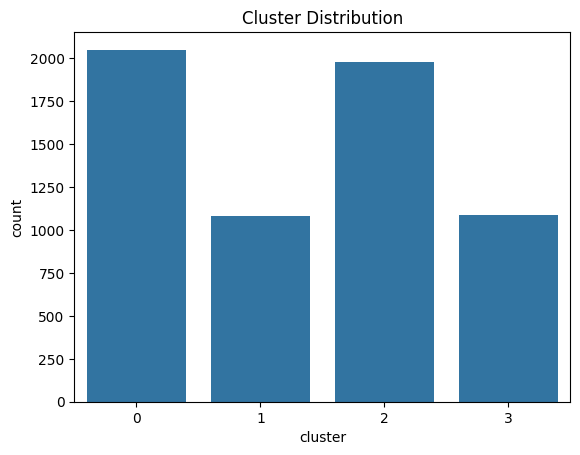

In [13]:
sns.countplot(x='cluster', data=df)
plt.title("Cluster Distribution")
plt.show()